In [165]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)
N, D = 1000, 4
p = 0.9
X = np.random.rand(N, D)
w1 = np.random.rand(D)
w2 = -w1
noise = 0.1 * np.random.randn(N)

y = np.zeros(N)
z = np.zeros(N, dtype=int)

for i in range(N):
    if np.random.rand() < p:
        y[i] = X[i] @ w1 + noise[i]
        z[i] = 1
    else:
        y[i] = X[i] @ w2 + noise[i]
        z[i] = 2

In [117]:
##### 1번 #####
# z==1에 해당하는 샘플만 사용
X_y1 = X[z == 1]
y_y1 = y[z == 1]

# 정규방정식을 이용한 선형 회귀
w_y1 = np.linalg.pinv(X_y1) @ y_y1

# 예측 및 성능 평가
y_pred = X @ w_y1
y_pred_y1 = y_pred[z == 1]

estimation_error = np.mean((y_y1 - y_pred_y1) ** 2)
weight_error = np.linalg.norm(w_y1 - w1)

print(f"Estimation Error (z==1 only): {estimation_error:.6f}")
print(f"Weight Error (L2 norm):      {weight_error:.6f}")
#print(f"weight", w_y1)
#print(f"true weight", w1)

Estimation Error (z==1 only): 0.010138
Weight Error (L2 norm):      0.028558


In [112]:
###### 2번 #####
w_all = np.linalg.pinv(X) @ y

# 예측값 계산
y_pred = X @ w_all

# z==1에 대해서만 평가
y_y1 = y[z == 1]
y_pred_y1 = y_pred[z == 1]

# 오차 계산
estimation_error = np.mean((y_y1 - y_pred_y1) ** 2)
weight_error = np.linalg.norm(w_all - w1)

print(f"Estimation Error (z==1 only): {estimation_error:.6f}")
print(f"Weight Error (L2 norm):      {weight_error:.6f}")
#print(f"weight", w_all)

Estimation Error (z==1 only): 0.027416
Weight Error (L2 norm):      0.131236


In [146]:
#### 3번 Gradient Descent method ####
# ====== 실험 함수 ======
def gradient_descent(init_type, batch_type, optimizer_type, learning_rate=0.01, num_epochs=1000, batch_size=32):
    np.random.seed(0)

    # 초기화
    if init_type == 'random':
        w = np.random.randn(D)
    elif init_type == 'zero':
        w = np.zeros(D)
    elif init_type == 'sparse':
        w = np.random.randn(D)
        w[np.random.rand(D) < 0.8] = 0

    m = np.zeros_like(w)
    v = np.zeros_like(w)
    grad_squared = np.zeros_like(w)
    running_avg = np.zeros_like(w)
    epsilon = 1e-8
    beta1, beta2 = 0.9, 0.999

    mse_history = []
    weight_error_history = []

    for epoch in range(1, num_epochs + 1):
        if batch_type == 'full':
            X_batch = X
            y_batch = y
        elif batch_type == 'mini-batch':
            indices = np.random.choice(N, batch_size, replace=False)
            X_batch = X[indices]
            y_batch = y[indices]
        elif batch_type == 'SGD':
            idx = np.random.randint(0, N)
            X_batch = X[idx:idx+1]
            y_batch = y[idx:idx+1]

        y_pred = X_batch @ w
        error = y_pred - y_batch
        gradient = (2 / X_batch.shape[0]) * X_batch.T @ error

        # Optimizer update
        if optimizer_type == 'GD':
            w -= learning_rate * gradient
        elif optimizer_type == 'AdaGrad':
            grad_squared += gradient ** 2
            w -= learning_rate * gradient / (np.sqrt(grad_squared) + epsilon)
        elif optimizer_type == 'RMSProp':
            running_avg = 0.9 * running_avg + 0.1 * (gradient ** 2)
            w -= learning_rate * gradient / (np.sqrt(running_avg) + epsilon)
        elif optimizer_type == 'Adam':
            m = beta1 * m + (1 - beta1) * gradient
            v = beta2 * v + (1 - beta2) * (gradient ** 2)
            m_hat = m / (1 - beta1 ** epoch)
            v_hat = v / (1 - beta2 ** epoch)
            w -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        # 성능 측정 (z==1에 대해서만)
        y_pred_all = X @ w
        mse_history.append(np.mean((y[z == 1] - y_pred_all[z == 1]) ** 2))
        weight_error_history.append(np.linalg.norm(w - w1))

    return w, mse_history[-1], mse_history, weight_error_history[-1], weight_error_history

# ====== 전체 실험 실행 ======
results = []
mse_histories = {}
weight_error_histories = {}

for init_type in ['random', 'zero', 'sparse']:
    for batch_type in ['full', 'mini-batch', 'SGD']:
        for optimizer_type in ['GD', 'AdaGrad', 'RMSProp', 'Adam']:
            w_pred, mse, mse_hist, weight_error, weight_hist = gradient_descent(init_type, batch_type, optimizer_type)
            results.append({
                'Init Type': init_type,
                'Batch Type': batch_type,
                'Optimizer': optimizer_type,
                'Estimation Error': mse,
                'Weight Error': weight_error
            })
            key = (optimizer_type, batch_type, init_type)
            mse_histories[key] = mse_hist
            weight_error_histories[key] = weight_hist

### 표 시각화 ###
df = pd.DataFrame(results)[['Optimizer', 'Batch Type', 'Init Type', 'Estimation Error', 'Weight Error']]
df['Optimizer'] = pd.Categorical(df['Optimizer'], categories=['GD', 'AdaGrad', 'RMSProp', 'Adam'], ordered=True)
df = df.sort_values(by=['Optimizer', 'Batch Type', 'Init Type']).reset_index(drop=True)
print(df)

   Optimizer  Batch Type Init Type  Estimation Error  Weight Error
0         GD         SGD    random          0.056094      0.309221
1         GD         SGD    sparse          0.084162      0.363039
2         GD         SGD      zero          0.068330      0.250949
3         GD        full    random          0.034301      0.333413
4         GD        full    sparse          0.036525      0.360079
5         GD        full      zero          0.027757      0.140556
6         GD  mini-batch    random          0.036292      0.334624
7         GD  mini-batch    sparse          0.038206      0.356872
8         GD  mini-batch      zero          0.030535      0.150817
9    AdaGrad         SGD    random          1.623103      1.935141
10   AdaGrad         SGD    sparse          0.288897      1.805406
11   AdaGrad         SGD      zero          0.071259      0.364454
12   AdaGrad        full    random          1.107759      1.798833
13   AdaGrad        full    sparse          0.248064      1.65

In [166]:
def ours(init_type, learning_rate, num_epochs, reset_interval=200, outlier_ratio=0.01):
    np.random.seed(0)

    # 전체 학습용 데이터 복사
    X_current = X.copy()
    y_current = y.copy()
    z_current = z.copy()  # 평가용

    mse_history = []
    weight_error_history = []

    for epoch in range(1, num_epochs + 1):

        # === 가중치 초기화 ===
        if epoch == 1 or (epoch - 1) % reset_interval == 0:
            if init_type == 'random':
                w = np.random.randn(D)
            elif init_type == 'zero':
                w = np.zeros(D)
            elif init_type == 'sparse':
                w = np.random.randn(D)
                w[np.random.rand(D) < 0.8] = 0
            m = np.zeros_like(w)
            v = np.zeros_like(w)
            beta1, beta2 = 0.9, 0.999
            epsilon = 1e-8
            t = 0  # Adam 타임스텝

        # Full batch 학습
        y_pred = X_current @ w
        error = y_pred - y_current
        gradient = (2 / X_current.shape[0]) * X_current.T @ error

        # Adam 업데이트
        t += 1
        m = beta1 * m + (1 - beta1) * gradient
        v = beta2 * v + (1 - beta2) * (gradient ** 2)
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        w -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        # === 성능 측정 (z==1만) ===
        y_pred_all = X @ w
        mse = np.mean((y[z == 1] - y_pred_all[z == 1]) ** 2)
        weight_error = np.linalg.norm(w - w1)
        mse_history.append(mse)
        weight_error_history.append(weight_error)

        # === 200 에포크마다 이상치 제거 및 재초기화 ===
        if epoch % reset_interval == 0 and epoch != num_epochs:
            residuals = np.abs(X_current @ w - y_current)
            cutoff = np.percentile(residuals, 100 * (1 - outlier_ratio))
            inlier_mask = residuals <= cutoff

            X_current = X_current[inlier_mask]
            y_current = y_current[inlier_mask]
            z_current = z_current[inlier_mask]

    return w, mse_history[-1], mse_history, weight_error_history[-1], weight_error_history


results = []
# 학습 실행
w, final_mse, mse_hist, final_weight_err, weight_err_hist = ours(
    init_type='random',
    learning_rate=0.01,
    num_epochs=999,
    reset_interval=200,
    outlier_ratio=0.1
)
# 결과 저장
results.append({
    'Optimizer': 'Outlier Removal',
    'Final MSE': final_mse,
    'Final Weight Error': final_weight_err,
    'MSE History': mse_hist,
    'Weight Error History': weight_err_hist
})
import pandas as pd

summary_table = pd.DataFrame([
    {
        'Optimizer': r['Optimizer'],
        'Final MSE': round(r['Final MSE'], 6),
        'Final Weight Error': round(r['Final Weight Error'], 6)
    }
    for r in results
])
print("최종 성능 요약:")
print(summary_table)

최종 성능 요약:
         Optimizer  Final MSE  Final Weight Error
0  Outlier Removal    0.01194             0.14898


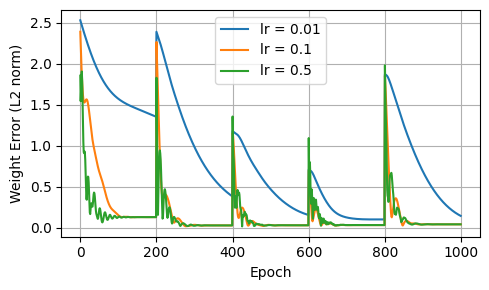

In [167]:
import matplotlib.pyplot as plt

learning_rates = [0.01, 0.1, 0.5]
ours_mse_histories = {}

for lr in learning_rates:
    w, final_mse, mse_hist, final_weight_err, weight_err_hist = ours(
        init_type='random',
        learning_rate=lr,
        num_epochs=1000,
        reset_interval=200,
        outlier_ratio=0.1
    )
    ours_mse_histories[lr] = weight_err_hist

plt.figure(figsize=(5, 3))
for lr in learning_rates:
    plt.plot(ours_mse_histories[lr], label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("Weight Error (L2 norm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()